## Junior Genius (Personal AI Learning Model) Module E
-------------------------

Problem Statement
Traditional educational systems often employ a one-size-fits-all approach, failing to cater to the unique learning pace, aptitudes, and deficiencies of individual students. This lack of personalization frequently results in inconsistent progress, demotivation, and failure to achieve full academic potential.


## Loading data set as (Df1= Final marks) and (Df2= Student Performance)


In [2]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
df = pd.read_csv('Final_Marks_Data.csv')
df2 =pd.read_csv('StudentsPerformance.csv')
print(df.head())
print(df2.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3                  3            

## Combined (Df1 and Df2 in Df3) and the total info of both

In [4]:
df3 = pd.concat([df, df2], axis=1)
print(df3.head())
print("----------------------------------------------------------------------------")
df3.info()
df3.head()
df3.isna().sum()


  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  gender race/ethnicity  \
0                  3                             72  female        group B   
1                  3                             56  female        group C   
2             

Student_ID                          0
Attendance (%)                      0
Internal Test 1 (out of 40)         0
Internal Test 2 (out of 40)         0
Assignment Score (out of 10)        0
Daily Study Hours                   0
Final Exam Marks (out of 100)       0
gender                           1000
race/ethnicity                   1000
parental level of education      1000
lunch                            1000
test preparation course          1000
math score                       1000
reading score                    1000
writing score                    1000
dtype: int64

## Df3 column complete info

In [5]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     2000 non-null   object 
 1   Attendance (%)                 2000 non-null   int64  
 2   Internal Test 1 (out of 40)    2000 non-null   int64  
 3   Internal Test 2 (out of 40)    2000 non-null   int64  
 4   Assignment Score (out of 10)   2000 non-null   int64  
 5   Daily Study Hours              2000 non-null   int64  
 6   Final Exam Marks (out of 100)  2000 non-null   int64  
 7   gender                         1000 non-null   object 
 8   race/ethnicity                 1000 non-null   object 
 9   parental level of education    1000 non-null   object 
 10  lunch                          1000 non-null   object 
 11  test preparation course        1000 non-null   object 
 12  math score                     1000 non-null   f

## Visual Representations

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.2)
df3.head()

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100),gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,S1000,84,30,36,7,3,72,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,S1001,91,24,38,6,3,56,female,group C,some college,standard,completed,69.0,90.0,88.0
2,S1002,73,29,26,7,3,56,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,S1003,80,36,35,7,3,74,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,S1004,84,31,37,8,3,66,male,group C,some college,standard,none,76.0,78.0,75.0


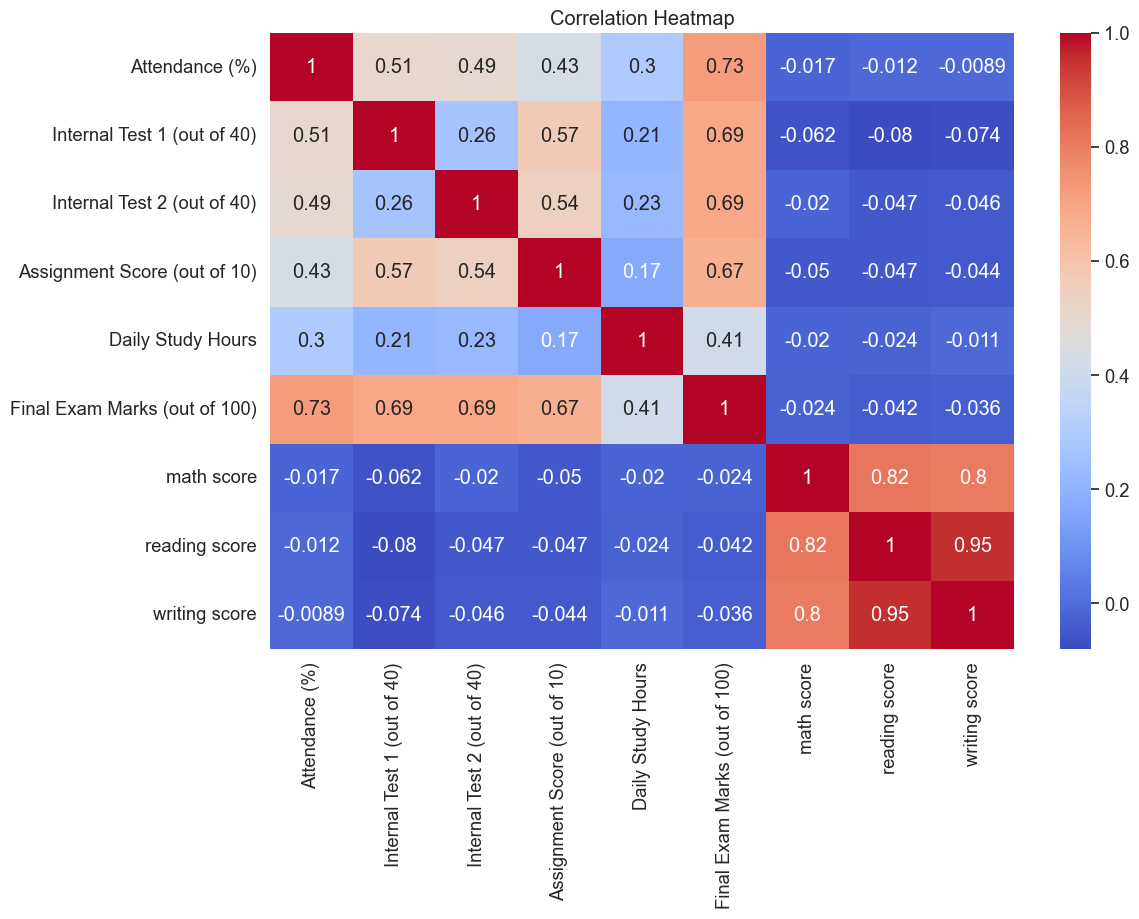

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df3.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

** For factors such as  gender", "race/ethnicity", "parental level of education","lunch" are of no use **

In [8]:
df3 = df3.drop(columns=["gender", "race/ethnicity", "parental level of education", "lunch"])
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     2000 non-null   object 
 1   Attendance (%)                 2000 non-null   int64  
 2   Internal Test 1 (out of 40)    2000 non-null   int64  
 3   Internal Test 2 (out of 40)    2000 non-null   int64  
 4   Assignment Score (out of 10)   2000 non-null   int64  
 5   Daily Study Hours              2000 non-null   int64  
 6   Final Exam Marks (out of 100)  2000 non-null   int64  
 7   test preparation course        1000 non-null   object 
 8   math score                     1000 non-null   float64
 9   reading score                  1000 non-null   float64
 10  writing score                  1000 non-null   float64
dtypes: float64(3), int64(6), object(2)
memory usage: 172.0+ KB


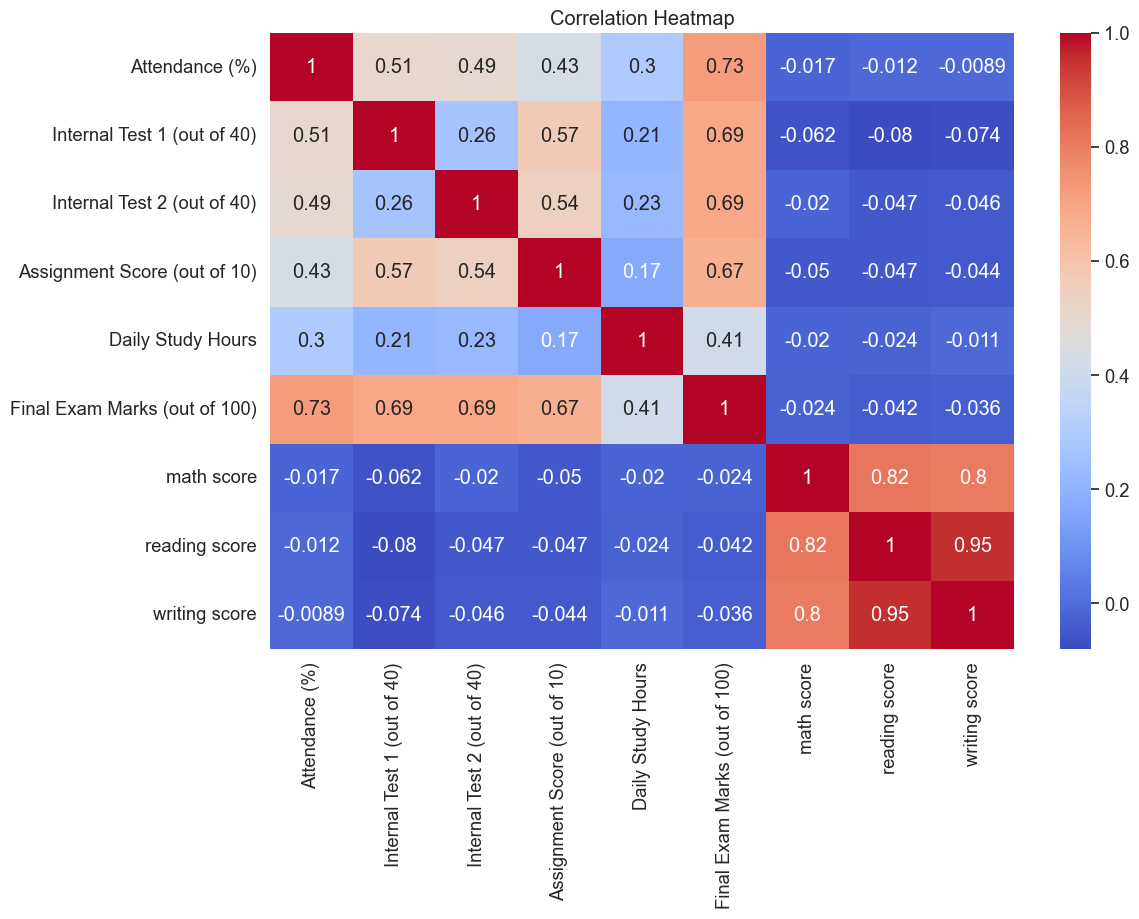

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df3.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Attendance vs Final Marks

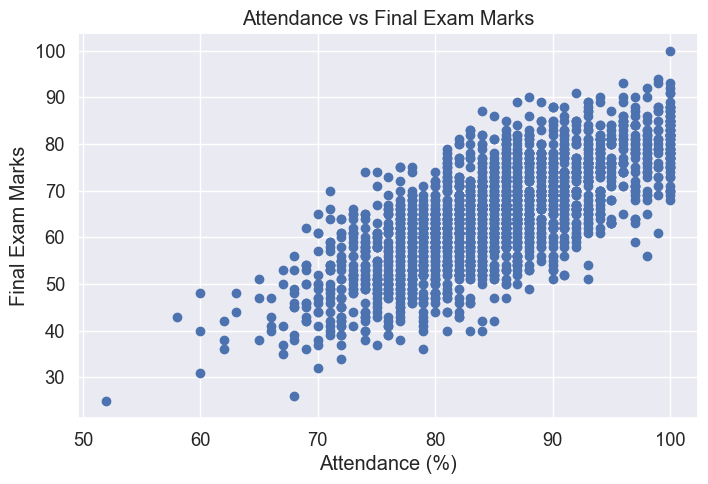

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df3["Attendance (%)"], df3["Final Exam Marks (out of 100)"])
plt.xlabel("Attendance (%)")
plt.ylabel("Final Exam Marks")
plt.title("Attendance vs Final Exam Marks")
plt.show()


## Daily Study


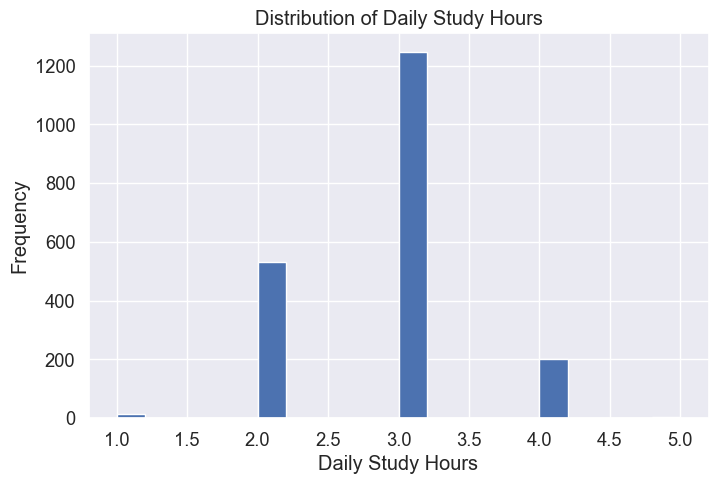

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Daily Study Hours"], bins=20)
plt.xlabel("Daily Study Hours")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Study Hours")
plt.show()


## Pairplot Daily Study and Final Exam Marks

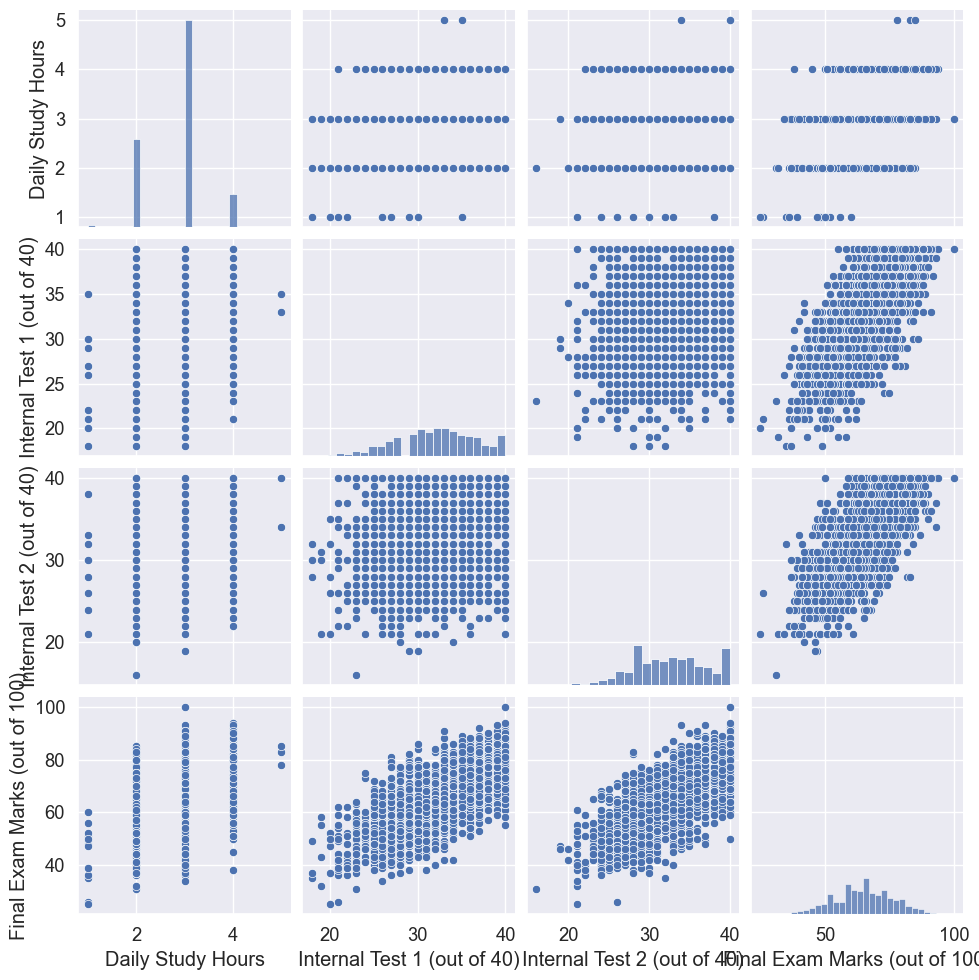

In [12]:
sns.pairplot(df[[
    "Daily Study Hours",
    "Internal Test 1 (out of 40)",
    "Internal Test 2 (out of 40)",
    "Final Exam Marks (out of 100)"
]])
plt.show()


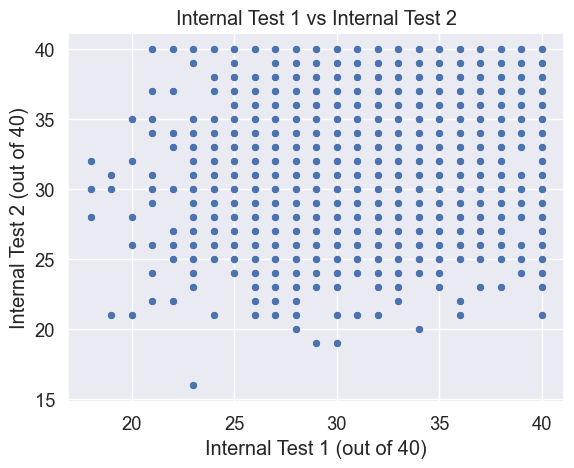

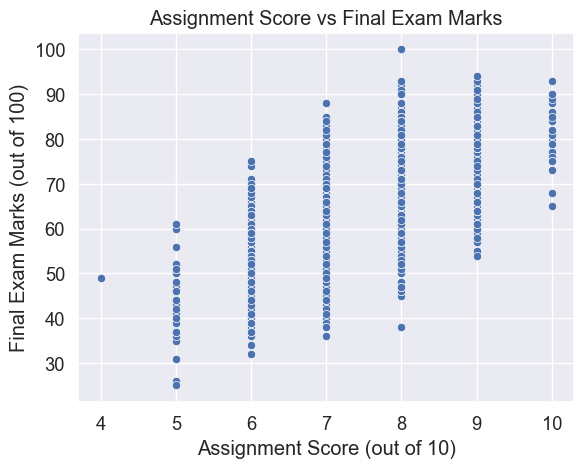

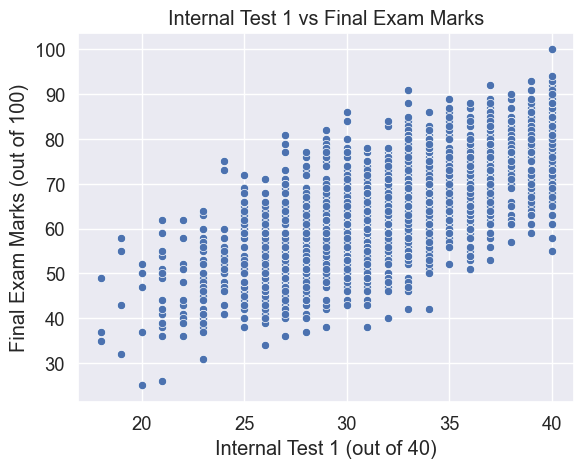

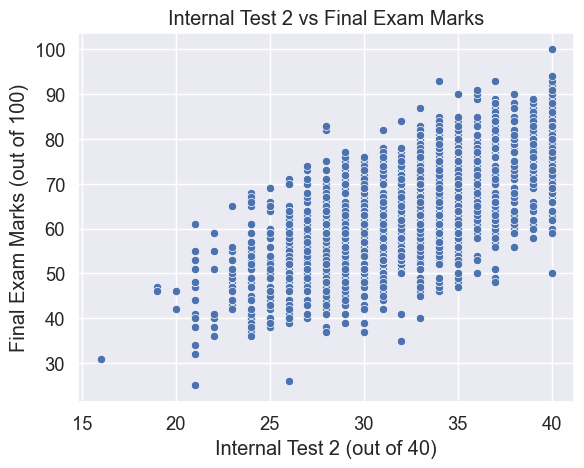

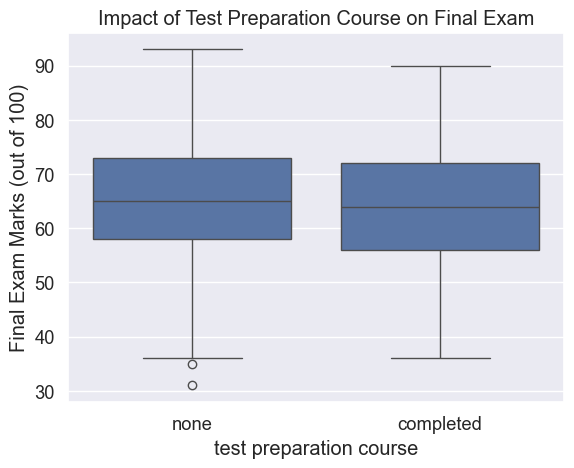

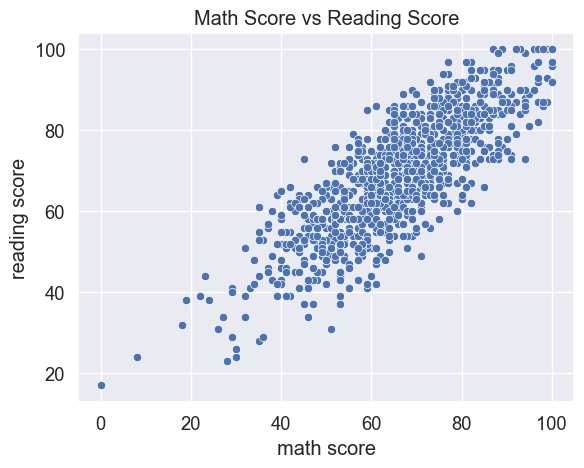

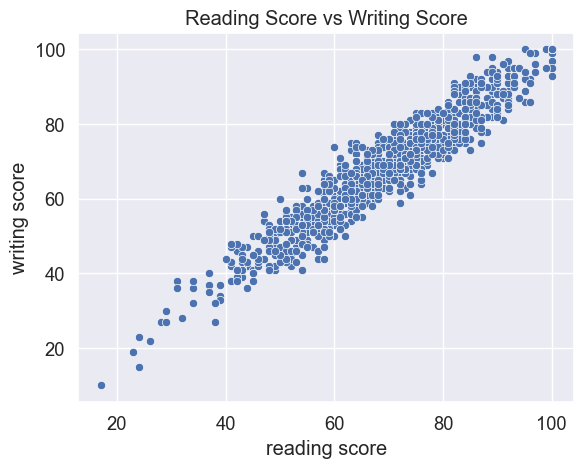

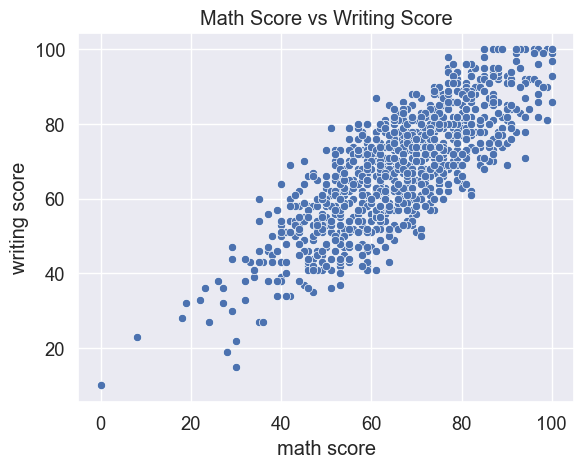

In [13]:
cols = [
    "Internal Test 1 (out of 40)",
    "Internal Test 2 (out of 40)",
    "Assignment Score (out of 10)",
    "Final Exam Marks (out of 100)",
    "test preparation course",
    "math score",
    "reading score",
    "writing score"
]

data = df3[cols]

sns.scatterplot(x=data[cols[0]], y=data[cols[1]])
plt.title("Internal Test 1 vs Internal Test 2")
plt.show()

sns.scatterplot(x=data[cols[2]], y=data[cols[3]])
plt.title("Assignment Score vs Final Exam Marks")
plt.show()

sns.scatterplot(x=data[cols[0]], y=data[cols[3]])
plt.title("Internal Test 1 vs Final Exam Marks")
plt.show()

sns.scatterplot(x=data[cols[1]], y=data[cols[3]])
plt.title("Internal Test 2 vs Final Exam Marks")
plt.show()

sns.boxplot(x=data["test preparation course"], y=data["Final Exam Marks (out of 100)"])
plt.title("Impact of Test Preparation Course on Final Exam")
plt.show()

sns.scatterplot(x=data["math score"], y=data["reading score"])
plt.title("Math Score vs Reading Score")
plt.show()

sns.scatterplot(x=data["reading score"], y=data["writing score"])
plt.title("Reading Score vs Writing Score")
plt.show()


sns.scatterplot(x=data["math score"], y=data["writing score"])
plt.title("Math Score vs Writing Score")
plt.show()


In [14]:
df3 = df3.dropna(subset=['Final Exam Marks (out of 100)'])


## Define Features

In [15]:
numeric_features = [
    'math score', 'reading score', 'writing score',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Attendance (%)',
    'Daily Study Hours'
]
numeric_features = [c for c in numeric_features if c in df3.columns]


In [16]:
categorical_features = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]
categorical_features = [c for c in categorical_features if c in df3.columns]


In [17]:
df3_encoded = pd.get_dummies(df3[categorical_features], drop_first=True)
X = pd.concat([df3[numeric_features].reset_index(drop=True),
               df3_encoded.reset_index(drop=True)], axis=1)


## MODEL 1: Regression (Predict Final Exam Marks)

In [18]:
y_reg = df3['Final Exam Marks (out of 100)']


Training models...
Linear Regression finished.
Ridge finished.
Lasso finished.
KNN finished.
SVR finished.
Decision Tree finished.
Random Forest finished.
--- Model Performance Leaderboard ---
               Model        R2      RMSE
1              Ridge  0.829214  4.688791
0  Linear Regression  0.829155  4.689607
2              Lasso  0.817041  4.853020
6      Random Forest  0.794150  5.147664
3                KNN  0.784080  5.272077
4                SVR  0.751782  5.652640
5      Decision Tree  0.569749  7.442110


C:\Users\Ayush Mishra\AppData\Local\Temp\ipykernel_21724\862685143.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Model", data=results_df, palette="viridis")


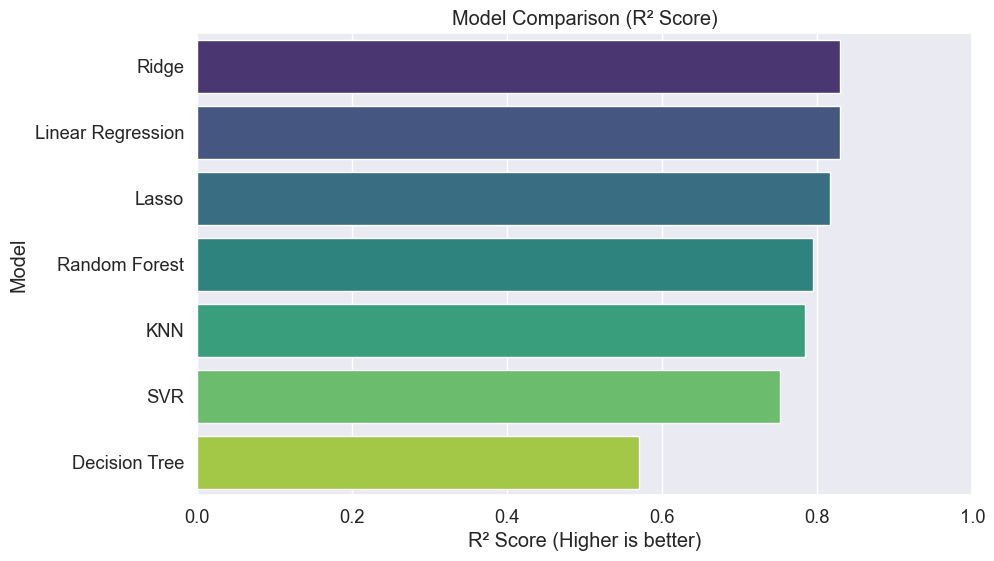

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor)

combined_data = pd.concat([X, y_reg], axis=1)
combined_data_cleaned = combined_data.dropna()

X_cleaned = combined_data_cleaned.drop(columns=y_reg.name)
y_cleaned = combined_data_cleaned[y_reg.name]
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)


models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    "Ridge": Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    "Lasso": Pipeline([('scaler', StandardScaler()), ('model', Lasso())]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())]),
    "SVR": Pipeline([('scaler', StandardScaler()), ('model', SVR())]),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),

}

results = []

print("Training models...")

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5


        results.append({"Model": name, "R2": r2, "RMSE": rmse})
        print(f"{name} finished.")

    except Exception as e:
        print(f"{name} failed: {e}")

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("--- Model Performance Leaderboard ---")
print(results_df)
plt.figure(figsize=(10, 6))
sns.barplot(x="R2", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison (R² Score)")
plt.xlabel("R² Score (Higher is better)")
plt.xlim(0, 1.0)
plt.show()

In [20]:
combined_data = pd.concat([X, y_reg], axis=1)
combined_data_cleaned = combined_data.dropna()
X_cleaned = combined_data_cleaned.drop(columns=y_reg.name)
y_cleaned = combined_data_cleaned[y_reg.name]
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

model_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
model_reg.fit(X_train, y_train)
y_pred = model_reg.predict(X_test)

print("Regression R²:", r2_score(y_test, y_pred))
print("Regression RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Regression R²: 0.8292142299287178
Regression RMSE: 4.6887905586134835


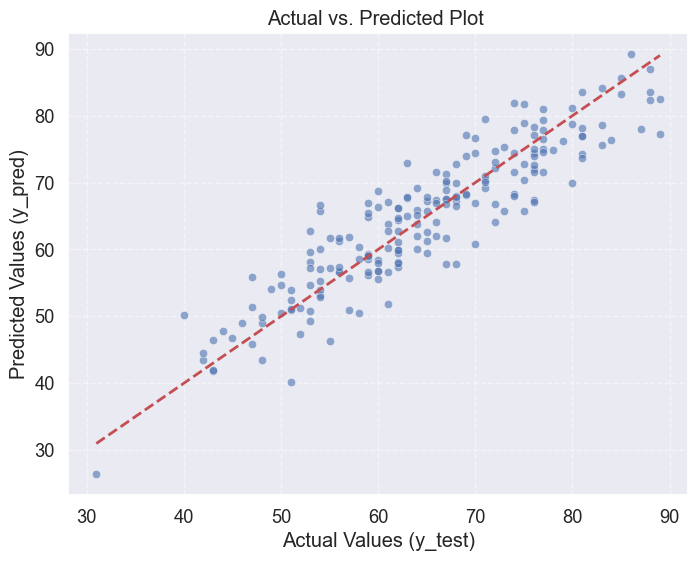

In [21]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Plot ')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**we will go with Ridge model for final marks prediction**



## Classifation of a person is he is pass or fail in the Final exam

In [22]:
df3['final_pass'] = (df3['Final Exam Marks (out of 100)'] >= 50).astype(int)
y_class_final = df3['final_pass']



========== Logistic Regression ==========
Accuracy: 0.9400
ROC AUC:  0.9732
------------------------------
              precision    recall  f1-score   support

           0       0.72      0.61      0.66        38
           1       0.96      0.98      0.97       362

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400


========== Random Forest ==========
Accuracy: 0.9500
ROC AUC:  0.9705
------------------------------
              precision    recall  f1-score   support

           0       0.82      0.61      0.70        38
           1       0.96      0.99      0.97       362

    accuracy                           0.95       400
   macro avg       0.89      0.80      0.83       400
weighted avg       0.95      0.95      0.95       400


========== Gradient Boosting ==========
Accuracy: 0.9375
ROC AUC:  0.9460
------------------------------
              precision    rec

C:\Users\Ayush Mishra\AppData\Local\Temp\ipykernel_21724\2774288104.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


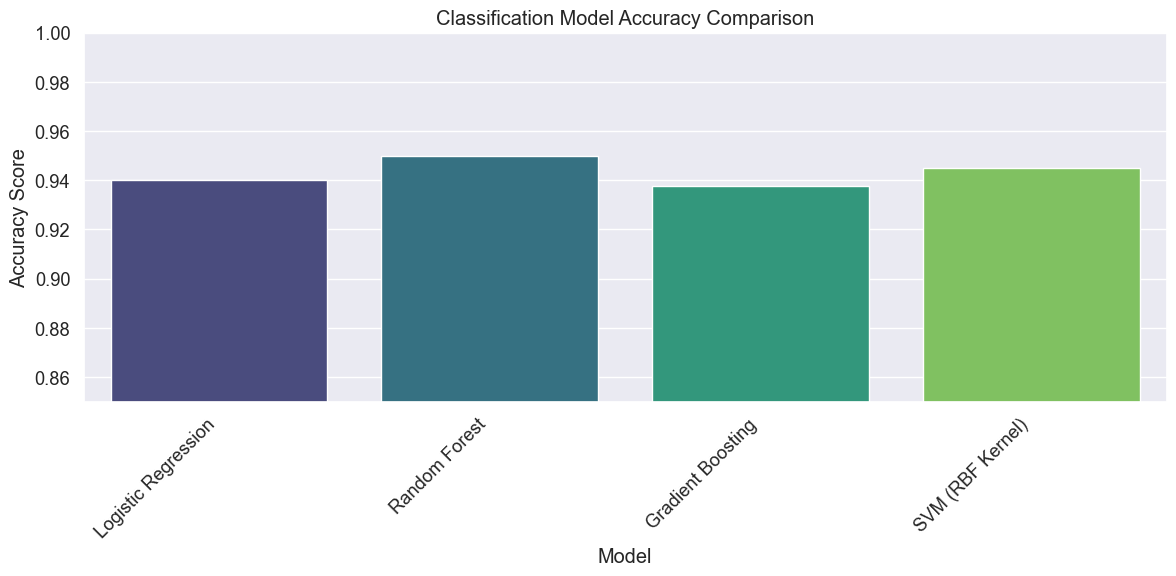

C:\Users\Ayush Mishra\AppData\Local\Temp\ipykernel_21724\2774288104.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC AUC', data=results_df, palette='magma')


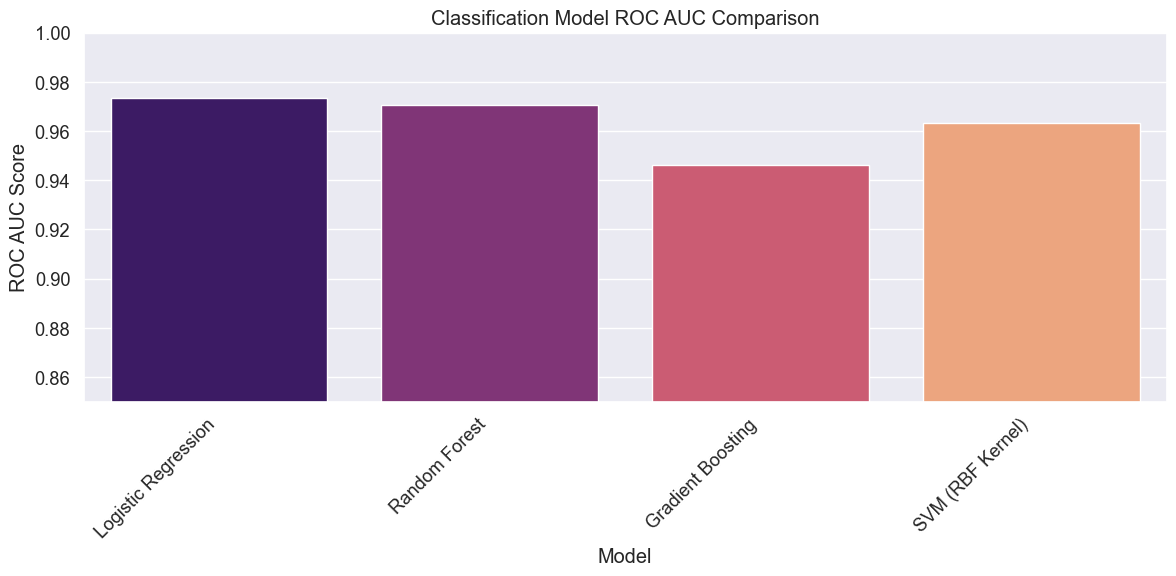

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    "Logistic Regression": Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    "Random Forest": Pipeline([('imputer', SimpleImputer(strategy='mean')), ('model', RandomForestClassifier(n_estimators=200, random_state=42))]),
    "Gradient Boosting": Pipeline([('imputer', SimpleImputer(strategy='mean')), ('model', GradientBoostingClassifier(n_estimators=200, random_state=42))]),
    "SVM (RBF Kernel)": Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler()), ('model', SVC(probability=True, random_state=42))])
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class_final, test_size=0.2, random_state=42
)

results = []

for name, clf_pipeline in models.items():
    print(f"\n========== {name} ==========")

    clf_pipeline.fit(X_train, y_train)

    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({"Model": name, "Accuracy": acc, "ROC AUC": auc})

    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC:  {auc:.4f}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Classification Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='ROC AUC', data=results_df, palette='magma')
plt.title('Classification Model ROC AUC Comparison')
plt.ylabel('ROC AUC Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Accuracy: 0.945
ROC AUC: 0.9698313463216051
              precision    recall  f1-score   support

           0       0.83      0.53      0.65        38
           1       0.95      0.99      0.97       362

    accuracy                           0.94       400
   macro avg       0.89      0.76      0.81       400
weighted avg       0.94      0.94      0.94       400

--- Confusion Matrix (Raw) ---


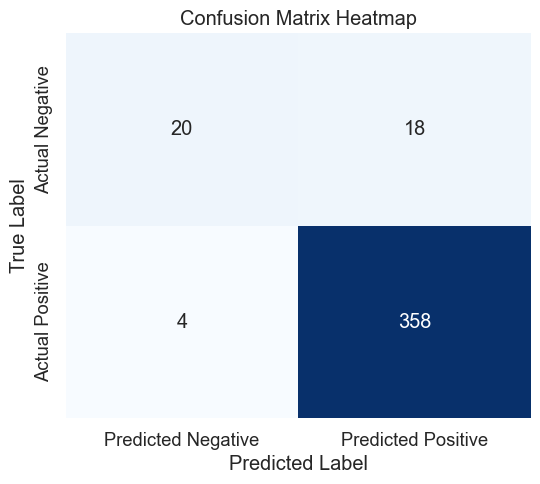

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y_class_final, test_size=0.2, random_state=42)

clf_final = RandomForestClassifier(n_estimators=200, random_state=42)
clf_final.fit(X_train, y_train)
y_pred = clf_final.predict(X_test)
y_proba = clf_final.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print("--- Confusion Matrix (Raw) ---")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

**We will go with  RandomForestClassifier for this**

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer # Import SimpleImputer

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class_final, test_size=0.2, random_state=42, stratify=y_class_final
)

# Instantiate imputer
imputer = SimpleImputer(strategy='mean')

# Impute missing values in X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert imputed arrays back to DataFrame for SMOTE and model
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

# 2. SMOTE Oversampling (applied on imputed data)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imputed, y_train)

print("Original:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

# 3. Balanced classifier
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# 4. Train
clf.fit(X_train_res, y_train_res)

# 5. Predict (using imputed X_test)
y_pred = clf.predict(X_test_imputed)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Original: final_pass
1    1450
0     150
Name: count, dtype: int64
After SMOTE: final_pass
1    1450
0    1450
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.58      0.66      0.62        38
           1       0.96      0.95      0.96       362

    accuracy                           0.92       400
   macro avg       0.77      0.80      0.79       400
weighted avg       0.93      0.92      0.92       400

[[ 25  13]
 [ 18 344]]


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_proba = clf.predict_proba(X_test)[:, 1]

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

print("THRESHOLD TUNING RESULTS")
print("==========================")

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    fail_recall = tn / (tn + fp)    # ability to catch FAIL students
    pass_recall = tp / (tp + fn)    # ability to catch PASS students
    acc = accuracy_score(y_test, y_pred_t)

    print(f"\nTHRESHOLD = {t}")
    print(cm)
    print(f"Fail Recall (neg class): {fail_recall:.3f}")
    print(f"Pass Recall (pos class): {pass_recall:.3f}")
    print(f"Accuracy: {acc:.3f}")


THRESHOLD TUNING RESULTS

THRESHOLD = 0.5
[[ 25  13]
 [ 18 344]]
Fail Recall (neg class): 0.658
Pass Recall (pos class): 0.950
Accuracy: 0.922

THRESHOLD = 0.45
[[ 25  13]
 [ 17 345]]
Fail Recall (neg class): 0.658
Pass Recall (pos class): 0.953
Accuracy: 0.925

THRESHOLD = 0.4
[[ 24  14]
 [ 16 346]]
Fail Recall (neg class): 0.632
Pass Recall (pos class): 0.956
Accuracy: 0.925

THRESHOLD = 0.35
[[ 22  16]
 [ 15 347]]
Fail Recall (neg class): 0.579
Pass Recall (pos class): 0.959
Accuracy: 0.922

THRESHOLD = 0.3
[[ 20  18]
 [ 11 351]]
Fail Recall (neg class): 0.526
Pass Recall (pos class): 0.970
Accuracy: 0.927

THRESHOLD = 0.25
[[ 17  21]
 [ 10 352]]
Fail Recall (neg class): 0.447
Pass Recall (pos class): 0.972
Accuracy: 0.922

THRESHOLD = 0.2
[[ 14  24]
 [  8 354]]
Fail Recall (neg class): 0.368
Pass Recall (pos class): 0.978
Accuracy: 0.920


Accuracy: 0.8875
ROC AUC: 0.9459872055830183

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.84      0.59        38
           1       0.98      0.89      0.93       362

    accuracy                           0.89       400
   macro avg       0.72      0.87      0.76       400
weighted avg       0.93      0.89      0.90       400


Confusion Matrix:
[[ 32   6]
 [ 39 323]]


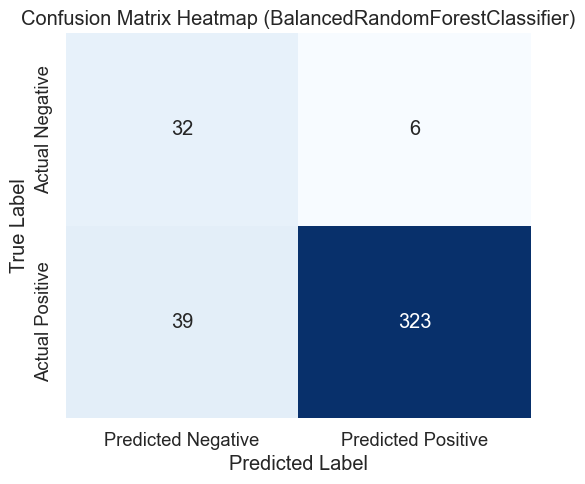

In [27]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train model
clf_bal = BalancedRandomForestClassifier(
    n_estimators=400,
    random_state=42,
    sampling_strategy="all",
    replacement=True
)

clf_bal.fit(X_train, y_train)

y_pred_bal = clf_bal.predict(X_test)
y_proba_bal = clf_bal.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("ROC AUC:", roc_auc_score(y_test, y_proba_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

print("\nConfusion Matrix:")
cm_bal = confusion_matrix(y_test, y_pred_bal)
print(cm_bal)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (BalancedRandomForestClassifier)')
plt.show()

## Recommendation system

In [28]:
def compute_skill_scores(row):
    return {
        "math_weak": row['math score'] < 50,
        "reading_weak": row['reading score'] < 50,
        "writing_weak": row['writing score'] < 50,
        "internal_low": (row['Internal Test 1 (out of 40)'] + row['Internal Test 2 (out of 40)']) / 2 < 20,
        "attendance_low": row['Attendance (%)'] < 60,
        "study_low": row['Daily Study Hours'] < 1.5
    }

skill_flags = df3.apply(compute_skill_scores, axis=1, result_type='expand')
df3 = pd.concat([df3, skill_flags], axis=1)
df3.head()


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100),test preparation course,math score,reading score,writing score,final_pass,math_weak,reading_weak,writing_weak,internal_low,attendance_low,study_low
0,S1000,84,30,36,7,3,72,none,72.0,72.0,74.0,1,False,False,False,False,False,False
1,S1001,91,24,38,6,3,56,completed,69.0,90.0,88.0,1,False,False,False,False,False,False
2,S1002,73,29,26,7,3,56,none,90.0,95.0,93.0,1,False,False,False,False,False,False
3,S1003,80,36,35,7,3,74,none,47.0,57.0,44.0,1,True,False,True,False,False,False
4,S1004,84,31,37,8,3,66,none,76.0,78.0,75.0,1,False,False,False,False,False,False


In [29]:
def compute_skill_scores(row):
    return {
        "math_weak": row['math score'] < 50,
        "reading_weak": row['reading score'] < 50,
        "writing_weak": row['writing score'] < 50,
        "internal_low": ((row['Internal Test 1 (out of 40)']
                          + row['Internal Test 2 (out of 40)']) / 2) < 20,
        "attendance_low": row['Attendance (%)'] < 60,
        "study_low": row['Daily Study Hours'] < 1.5,
        "math_strong": row['math score'] >= 75,
        "reading_strong": row['reading score'] >= 75,
        "writing_strong": row['writing score'] >= 75
    }
all_skill_flags = df3.apply(compute_skill_scores, axis=1, result_type="expand")

skill_flag_columns = all_skill_flags.columns
df3 = df3.drop(columns=skill_flag_columns, errors='ignore')
df3 = df3.join(all_skill_flags)

In [30]:
topic_map = {
    "math_weak": ["Fractions", "Number Sense", "Basic Algebra"],
    "reading_weak": ["Reading Comprehension", "Vocabulary"],
    "writing_weak": ["Grammar", "Sentence Structure"],
    "internal_low": ["Revision Sessions", "Past Papers"],
    "attendance_low": ["Study Habits", "Time Management"],
    "study_low": ["Daily Schedule Planning"]
}

advanced_topic_map = {
    "math_strong": ["Algebra Level 2", "Geometry Basics", "Word Problems"],
    "reading_strong": ["Advanced Vocabulary", "Long Passage Analysis"],
    "writing_strong": ["Essay Writing", "Creative Writing Practice"]
}
general_topics = [
    "General Practice Pack",
    "Moderate Mixed Worksheets",
    "Weekly Review Exercise"
]
intervention_map = {
    "math_weak": "Assign 10 math practice problems daily.",
    "reading_weak": "Give 15-min reading tasks daily.",
    "writing_weak": "Grammar worksheets + writing drills.",
    "internal_low": "Weekly revision + 2 mock tests.",
    "attendance_low": "Create a fixed study timetable.",
    "study_low": "Introduce 45-min focused study routine."
}


In [31]:
df3['fail_prob'] = clf_bal.predict_proba(X)[:, 0]
df3['risk_level'] = pd.cut(
    df3['fail_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)


In [32]:
risk_reco = {
    "High": [
        "High Priority Revision Set",
        "Teacher Intervention Required",
        "Daily Target Practice (30 mins)",
        "Redo Wrong Questions Pack"
    ],

    "Medium": [
        "Focused Practice Set",
        "Weekly Mock Test",
        "Topic-wise Revision Worksheets"
    ],

    "Low": [
        "General Practice Pack",
        "Skill Booster Set",
        "Moderate Mixed Worksheets"
    ]
}


In [33]:
def recommend_for_student(row):

    topics = []
    interventions = []

    if row['risk_level'] == "High":
        topics = [
            "High Priority Revision Set",
            "Redo Wrong Questions Pack",
            "Daily Target Practice (30 mins)",
            "Fundamental Skill Reinforcement"
        ]

        interventions = [
            "Teacher Intervention Required",
            "Strict Weekly Learning Plan",
            "Daily micro-practice tasks"
        ]

        return list(set(topics)), list(set(interventions))

    for weakness in topic_map.keys():
        if row.get(weakness) == True:
            topics.extend(topic_map[weakness])
            interventions.append(intervention_map[weakness])

    for strength in advanced_topic_map.keys():
        if row.get(strength) == True:
            topics.extend(advanced_topic_map[strength])

    if len(topics) == 0:
        risk = row['risk_level']
        topics.extend(risk_reco.get(risk, general_topics))


    return list(set(topics)), list(set(interventions))

In [34]:
i = 854
student = df3.iloc[i]
topics, actions = recommend_for_student(student)

print("\n===== STUDENT", i, "=====")
print("Risk Level:", student['risk_level'])
print("Fail Probability:", round(student['fail_prob'], 3))
print("\nRecommended Topics:", topics)
print("Recommended Interventions:", actions)


===== STUDENT 854 =====
Risk Level: Low
Fail Probability: 0.025

Recommended Topics: ['Moderate Mixed Worksheets', 'Skill Booster Set', 'General Practice Pack']
Recommended Interventions: []


In [35]:
artifacts = {}

artifacts['df'] = df3
artifacts['classification_model'] = clf_final
artifacts['regression_model'] = model_reg
artifacts['imputer'] = imputer
artifacts['topic_map'] = topic_map
artifacts['advanced_topic_map'] = advanced_topic_map
artifacts['intervention_map'] = intervention_map
artifacts['risk_reco'] = risk_reco
artifacts['general_topics'] = general_topics
artifacts['numeric_features'] = numeric_features
artifacts['categorical_features'] = categorical_features

print("Artifacts dictionary created with the following keys:")
for key in artifacts.keys():
    print(f"- {key}")

Artifacts dictionary created with the following keys:
- df
- classification_model
- regression_model
- imputer
- topic_map
- advanced_topic_map
- intervention_map
- risk_reco
- general_topics
- numeric_features
- categorical_features


In [36]:
import pickle

# Define the filename for the serialized artifacts
artifact_filename = 'student_performance_artifacts.pkl'

# Open the file in write-binary mode and dump the artifacts dictionary
with open(artifact_filename, 'wb') as f:
    pickle.dump(artifacts, f)

print(f"Artifacts successfully serialized to {artifact_filename}")

Artifacts successfully serialized to student_performance_artifacts.pkl


Project deployed link : https://personal-ai-learning-model.vercel.app/